In [17]:
import pandas as pd

dataframe = pd.read_csv(
    "../data/sentences.csv.zip",
    index_col=False,
    compression="zip",
)

In [18]:
dataframe.shape

(2264, 2)

In [19]:
dataframe.head()

,phrase,target
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [20]:
dataframe.target.value_counts()

target
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

In [21]:

for i in range(5):
   print(dataframe[dataframe.target == "positive"]["phrase"].iloc[i])

For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m 
In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn 
Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales 
Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales 
Finnish Talentum reports its operating profit increased to EUR 20.5 mn in 2005 from EUR 9.3 mn in 2004 , and net sales totaled EUR 103.3 mn , up from EUR 96.4 mn 


In [22]:
for i in range(5):
    print(dataframe[dataframe.target == "negative"]["phrase"].iloc[i])

Jan. 6 -- Ford is struggling in the face of slowing truck and SUV sales and a surfeit of up-to-date , gotta-have cars 
Pharmaceuticals group Orion Corp reported a fall in its third-quarter earnings that were hit by larger expenditures on R&D and marketing 
However , the growth margin slowed down due to the financial crisis 
2009 3 February 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , said today it slipped to a larger-than-expected pretax loss of EUR46m in the fourth quarter of 2009 from a year-earlier profit of EUR45m 
( ADPnews ) - Feb 3 , 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , said today it slipped to a larger-than-expected pretax loss of EUR 46 million ( USD 64.5 m ) in the fourth quarter of 2009 from 


In [23]:
for i in range(5):
    print(dataframe[dataframe.target == "neutral"]["phrase"].iloc[i])

According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing 
At the request of Finnish media company Alma Media 's newspapers , research manager Jari Kaivo-oja at the Finland Futures Research Centre at the Turku School of Economics has drawn up a future scenario for Finland 's national economy by using a model developed by the University of Denver 
STOCK EXCHANGE ANNOUNCEMENT 20 July 2006 1 ( 1 ) BASWARE SHARE SUBSCRIPTIONS WITH WARRANTS AND INCREASE IN SHARE CAPITAL A total of 119 850 shares have been subscribed with BasWare Warrant Program 
A maximum of 666,104 new shares can further be subscribed for by exercising B options under the 2004 stock option plan 
Tiimari operates 194 stores in six countries -- including its core Finnish market -- and generated a turnover of 76.5 mln eur in 2005 


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    dataframe.phrase, 
    dataframe.target, 
    test_size=0.3, 
    shuffle=False,
)

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    lowercase=True,
    analyzer="word",
    token_pattern=r"\b[a-zA-Z]\w+\b",
    stop_words="english",
    max_df=0.99,
    min_df=2,
    binary=True,
)

vectorizer.fit(X_train)

vectorizer.get_feature_names_out()

array(['ab', 'able', 'abp', ..., 'years', 'yesterday', 'yit'],
      dtype=object)

In [26]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

X_train_vectorized = vectorizer.transform(X_train)

clf.fit(
    X_train_vectorized,
    y_train,
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Probar modelo y muestra de entrenamiento

In [27]:
from sklearn.metrics import accuracy_score


accuracy_score(
    y_true=y_train,
    y_pred=clf.predict(X_train_vectorized),
)


0.9924242424242424

In [28]:
X_test_vectorized = vectorizer.transform(X_test)
predictions = clf.predict(X_test_vectorized)

accuracy_score(
    y_true=y_test,
    y_pred=predictions,
)

0.5338235294117647

Confusion matrix:
[[  2  78 189]
 [  0 344  39]
 [  0  11  17]]


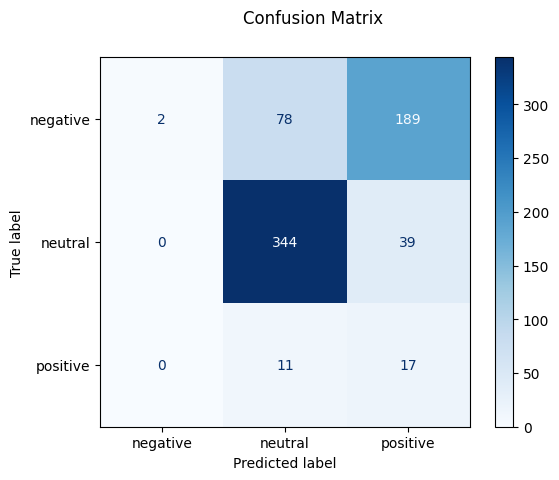

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Blues",
)
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")


In [30]:
import pickle

with open("../submission/clf.pkl", "wb") as file:
    pickle.dump(clf, file)

with open("../submission/vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

In [31]:
with open("../submission/clf.pkl", "rb") as file:
    new_clf = pickle.load(file)

with open("../submission/vectorizer.pkl", "rb") as file:
    new_vectorizer = pickle.load(file)

accuracy_score(
    y_true=dataframe.target,
    y_pred=new_clf.predict(new_vectorizer.transform(dataframe.phrase)),
)

0.8546819787985865